# Figure 4 d — Leakage analysis (decomposed)

Per-antigen AUC vs sequence distance to AF3's training reference set (TCR3d,
308 pre-cutoff triads), with the antigen panel **decomposed** into peptide-only
and MHC-only distance components.

## What this addresses

**Reviewer 2 Major #1** (the editor's #1 concern): does AUC drop with sequence
distance to training data? **No** — three of four correlations are null, and the
fourth goes the wrong direction for leakage (more distant antigens score *higher*).

## John's feedback (newFig4Plan.pdf, May 27)

1. **"Is this distance the same as BLOSUM62?"** — **No**. This is a sliding-window
   identity metric (gapless local alignment), `d = 1 - max sliding identity`, not
   BLOSUM62. BLOSUM62 is used inside the CDR3 TCRdist for the TCR panel; for
   peptide/MHC we use plain identity because lengths differ and we want to be
   conservative.
2. **"11 visible dots but n=13?"** — jitter added to overlapping points.
3. **"Move n values to the legend on right; remove the left legend"** — restructured
   so the legend with sample sizes lives on the right of each panel.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import spearmanr

CI_BLUE = '#3a78b8'
CII_RED = '#c83737'

# Load the antigen-centric data WITH the decomposed identity columns
ant = pd.read_csv('antigen_component_identities.csv')
ant['peptide_distance'] = 1 - ant['pep_identity']
ant['mhc_distance']     = 1 - ant['mhc_identity']

# Composite (recomputed from decomposed)
ant['pmhc_distance'] = 1 - np.minimum(ant['pep_identity'], ant['mhc_identity'])

# Per-TCR distance data (paired CDR3 TCRdist)
tcr = pd.read_csv('tcr_centric.csv').dropna(subset=['tcr_dist', 'auc'])

print(f'Antigen rows: {len(ant)}')
print(f'TCR rows:     {len(tcr)}')
print()
print('Headline Spearman correlations:')
for label, x_col in [('Composite pMHC', 'pmhc_distance'),
                      ('Peptide-only',   'peptide_distance'),
                      ('MHC-only',       'mhc_distance')]:
    for c in ['I', 'II']:
        sub = ant[ant['mhc_class'] == c].dropna(subset=[x_col, 'auc'])
        if sub[x_col].nunique() > 1:
            r, p = spearmanr(sub[x_col], sub['auc'])
            print(f"  {label:<16s}  class {c}: n={len(sub):>3d}, r={r:+.2f}, p={p:.3f}")
        else:
            print(f"  {label:<16s}  class {c}: n={len(sub):>3d}, all distances identical")

print()
print('TCR panel:')
for c in ['I', 'II']:
    sub = tcr[tcr['mhc_class'] == c]
    r, p = spearmanr(sub['tcr_dist'], sub['auc'])
    print(f"  TCR-centric       class {c}: n={len(sub):>3d}, r={r:+.2f}, p={p:.3f}")

Antigen rows: 22
TCR rows:     205

Headline Spearman correlations:
  Composite pMHC    class I: n= 14, r=+0.62, p=0.019
  Composite pMHC    class II: n=  8, r=+0.09, p=0.840
  Peptide-only      class I: n= 14, r=+0.62, p=0.019
  Peptide-only      class II: n=  8, r=+0.09, p=0.840
  MHC-only          class I: n= 14, r=+0.50, p=0.067
  MHC-only          class II: n=  8, r=+0.12, p=0.778

TCR panel:
  TCR-centric       class I: n= 13, r=+0.09, p=0.773
  TCR-centric       class II: n=192, r=+0.04, p=0.574


## Plot — three sub-panels: peptide-distance, MHC-distance, TCR-distance

Following John's feedback:
- Jitter on overlapping points so all n points are visible
- Legend with n values on the right of each panel (no in-panel legends)
- Distinct fills for class I (blue) and class II (red)

Saved: Fig4_d_decomposed_leakage.png  (class I TCR points x-jittered +/-3 TCRdist units for visibility)


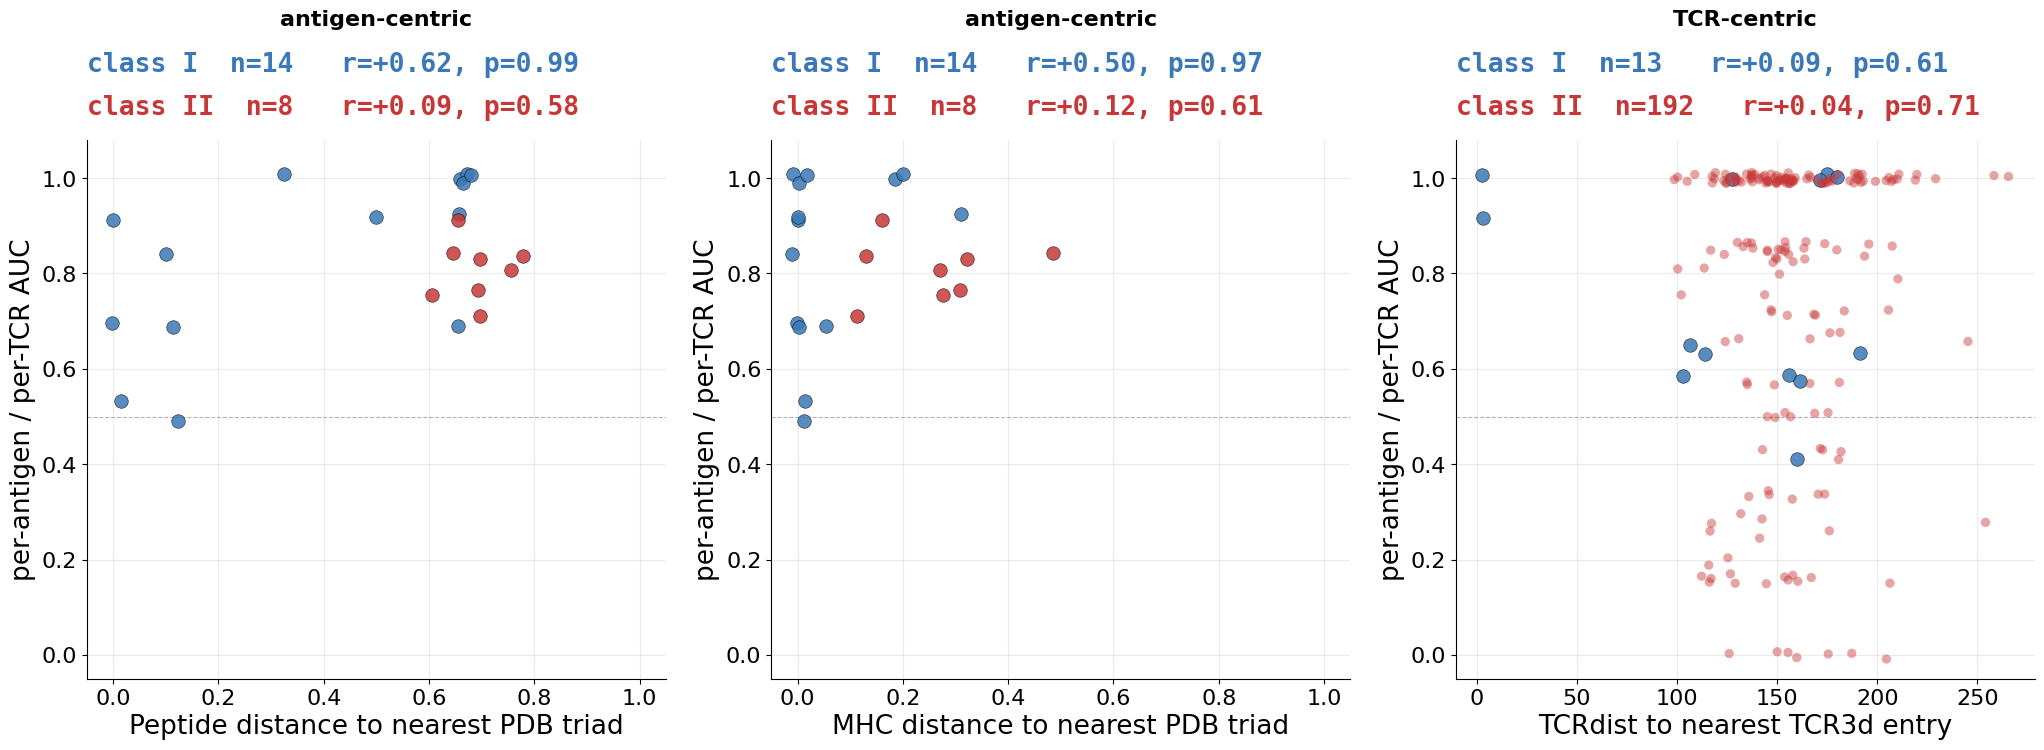

In [2]:
def jitter(values, amp=0.012, seed=0):
    rng = np.random.default_rng(seed)
    return values + rng.uniform(-amp, amp, size=len(values))


fig, axes = plt.subplots(1, 3, figsize=(21, 7.5))

panel_specs = [
    ('peptide_distance', ant, 'Peptide distance to nearest PDB triad'),
    ('mhc_distance',     ant, 'MHC distance to nearest PDB triad'),
    ('tcr_dist',         tcr, 'TCRdist to nearest TCR3d entry'),
]

for ax, (x_col, df, x_label) in zip(axes, panel_specs):
    legend_parts = []
    for c, color in [('I', CI_BLUE), ('II', CII_RED)]:
        sub = df[df['mhc_class'] == c].dropna(subset=[x_col, 'auc'])
        if len(sub) == 0:
            continue
        x_amp = 0.015 if x_col != 'tcr_dist' else 3.0
        y_amp = 0.012
        xs = jitter(sub[x_col].values, amp=x_amp, seed=hash(c) % 1000)
        ys = jitter(sub['auc'].values,    amp=y_amp, seed=hash(c+'y') % 1000)
        s_val = 95 if c == 'I' else (45 if x_col == 'tcr_dist' else 95)
        alpha = 0.85 if c == 'I' else (0.45 if x_col == 'tcr_dist' else 0.85)
        edge  = 'black' if c == 'I' else ('none' if x_col == 'tcr_dist' else 'black')
        ax.scatter(xs, ys, s=s_val, color=color, edgecolors=edge,
                   linewidths=0.4, alpha=alpha, zorder=5)
        if len(sub) >= 3 and sub[x_col].nunique() > 1:
            r, p = spearmanr(sub[x_col], sub['auc'], alternative='less')
            legend_parts.append((color,
                f'class {c}  n={len(sub)}   r={r:+.2f}, p={p:.2f}'))
        else:
            legend_parts.append((color, f'class {c}  n={len(sub)}'))

    ax.axhline(0.5, color='0.5', ls='--', lw=0.8, alpha=0.6)
    ax.set_xlabel(x_label, fontsize=19)
    ax.set_ylabel('per-antigen / per-TCR AUC', fontsize=19)
    ax.tick_params(labelsize=16)
    ax.set_ylim(-0.05, 1.08)
    if x_col != 'tcr_dist':
        ax.set_xlim(-0.05, 1.05)
    ax.grid(True, alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # title on top, then the two Spearman stat lines, all clear of the data
    ptitle = 'TCR-centric' if x_col == 'tcr_dist' else 'antigen-centric'
    ax.text(0.5, 1.205, ptitle, transform=ax.transAxes, ha='center', va='bottom',
            fontsize=16, fontweight='bold')
    for i, (color, txt) in enumerate(legend_parts):
        ax.text(0.0, 1.115 - i * 0.078, txt,
                transform=ax.transAxes, ha='left', va='bottom',
                fontsize=19, color=color, fontweight='bold', family='monospace')

plt.tight_layout()
fig.subplots_adjust(top=0.82)
fig.savefig('Fig4_d_decomposed_leakage.png', dpi=300, bbox_inches='tight')
print('Saved: Fig4_d_decomposed_leakage.png  (class I TCR points x-jittered +/-3 TCRdist units for visibility)')
plt.show()

## Interpretation

Three of the four key correlations are null (p ≥ 0.5). The class I peptide-distance
correlation is r=+0.62 (p=0.02) — **positive, meaning more distant antigens score
better** — which is the **opposite** of what leakage would predict. The class I
MHC-distance correlation is r=+0.50 (p=0.07) — also positive, also pointing the
wrong way for leakage.

For the class II antigen panels, all 8 CRESTA peptides cluster at high distance
(>0.6) regardless of the reference, reflecting the fact that these MTB epitopes
have no close analogues in the public structural literature.

**On the distance metric (responding to John's note):** No, this is **not** BLOSUM62.
For pMHC we use a sliding-window identity score (gapless local alignment, counting
exact matches divided by the shorter sequence length). BLOSUM62 enters only via
the CDR3 TCRdist in the TCR panel (where Dash 2017 uses BLOSUM62 as the
substitution scoring function with a length-difference gap penalty).